In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from PIL import Image

warnings.filterwarnings("ignore")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
ROOT = "/kaggle/input/datasets/mostahidhossain/azheimer-mri"

print("Dataset Root:")
print(ROOT)

Dataset Root:
/kaggle/input/datasets/mostahidhossain/azheimer-mri


In [3]:
root_folders = sorted(os.listdir(ROOT))

print("Folders Found:")
print(root_folders)

Folders Found:
['test-20260720T180555Z-1-001', 'train-20260720T180814Z-1-001']


In [4]:
train_folder = None
test_folder = None

for folder in root_folders:

    if folder.startswith("train"):
        train_folder = folder

    elif folder.startswith("test"):
        test_folder = folder

TRAIN_DIR = os.path.join(ROOT, train_folder, "train")
TEST_DIR = os.path.join(ROOT, test_folder, "test")

print("Train Directory")
print(TRAIN_DIR)

print()

print("Test Directory")
print(TEST_DIR)

Train Directory
/kaggle/input/datasets/mostahidhossain/azheimer-mri/train-20260720T180814Z-1-001/train

Test Directory
/kaggle/input/datasets/mostahidhossain/azheimer-mri/test-20260720T180555Z-1-001/test


In [5]:
print("Training Classes")
print(sorted(os.listdir(TRAIN_DIR)))

print()

print("Testing Classes")
print(sorted(os.listdir(TEST_DIR)))

Training Classes
['AD', 'CN', 'MCI']

Testing Classes
['AD', 'CN', 'MCI']


In [6]:
VALID_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
)

image_paths = []
labels = []
splits = []

def load_images(dataset_path, split_name):

    for label in sorted(os.listdir(dataset_path)):

        class_folder = os.path.join(dataset_path, label)

        if not os.path.isdir(class_folder):
            continue

        for root, dirs, files in os.walk(class_folder):

            for file in files:

                if file.lower().endswith(VALID_EXTENSIONS):

                    image_paths.append(os.path.join(root, file))
                    labels.append(label)
                    splits.append(split_name)

load_images(TRAIN_DIR, "Train")
load_images(TEST_DIR, "Test")

print("Total Images Loaded :", len(image_paths))

Total Images Loaded : 5154


In [7]:
df = pd.DataFrame({

    "image_path": image_paths,
    "label": labels,
    "split": splits

})

df.head()

,image_path,label,split
0,/kaggle/input/datasets/mostahidhossain/azheime...,AD,Train
1,/kaggle/input/datasets/mostahidhossain/azheime...,AD,Train
2,/kaggle/input/datasets/mostahidhossain/azheime...,AD,Train
3,/kaggle/input/datasets/mostahidhossain/azheime...,AD,Train
4,/kaggle/input/datasets/mostahidhossain/azheime...,AD,Train


In [8]:
sample_path = df.iloc[0]["image_path"]

print(sample_path)

print()

print("Is Image File?")

print(os.path.isfile(sample_path))

/kaggle/input/datasets/mostahidhossain/azheimer-mri/train-20260720T180814Z-1-001/train/AD/AD136_S_0426a120.png

Is Image File?
True


In [9]:
print("="*50)
print("DATASET SUMMARY")
print("="*50)

print(f"Total Images       : {len(df)}")

print(f"Number of Classes  : {df['label'].nunique()}")

print()

print("Class Names")

print(df["label"].unique())

print()

print("Images Per Class")

print(df["label"].value_counts())

print()

print("Train/Test Split")

print(df["split"].value_counts())

DATASET SUMMARY
Total Images       : 5154
Number of Classes  : 3

Class Names
['AD' 'CN' 'MCI']

Images Per Class
label
MCI    2590
CN     1440
AD     1124
Name: count, dtype: int64

Train/Test Split
split
Train    4123
Test     1031
Name: count, dtype: int64


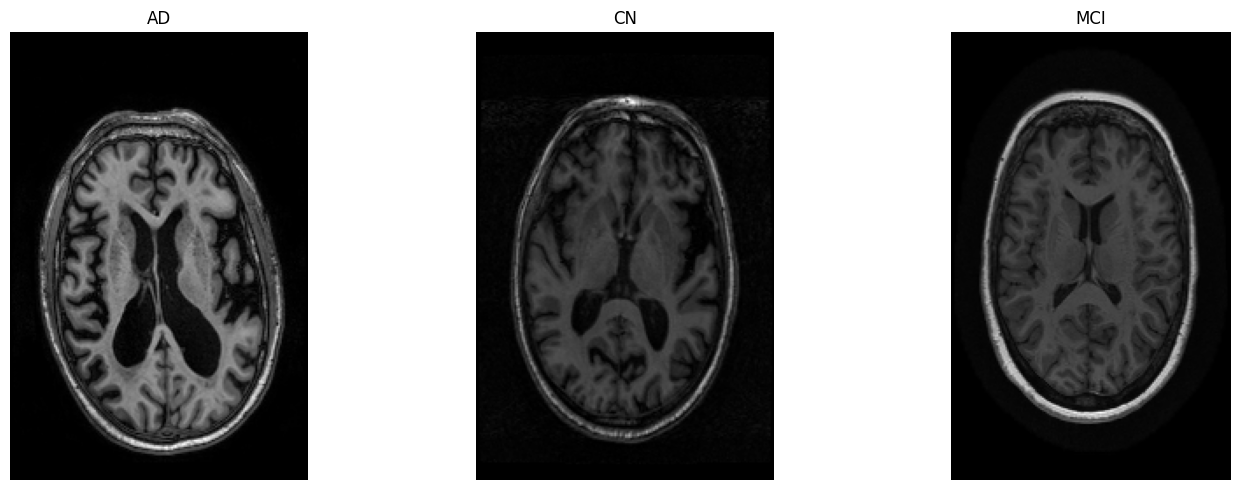

In [10]:
classes = sorted(df["label"].unique())

fig, axes = plt.subplots(
    1,
    len(classes),
    figsize=(15,5)
)

if len(classes) == 1:
    axes = [axes]

for ax, label in zip(axes, classes):

    sample = df[df["label"] == label].iloc[0]["image_path"]

    img = Image.open(sample)

    ax.imshow(img, cmap="gray")

    ax.set_title(label)

    ax.axis("off")

plt.tight_layout()

plt.show()

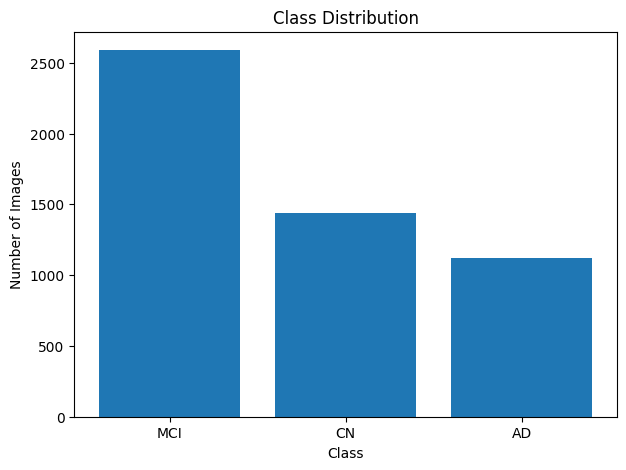

In [11]:
class_counts = df["label"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(
    class_counts.index,
    class_counts.values
)

plt.xlabel("Class")

plt.ylabel("Number of Images")

plt.title("Class Distribution")

plt.show()

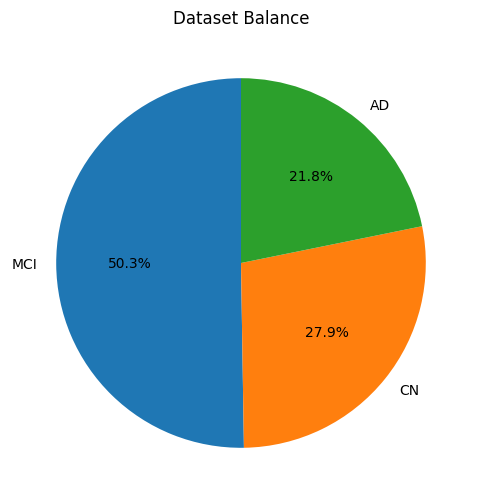

In [12]:
plt.figure(figsize=(6,6))

plt.pie(

    class_counts.values,

    labels=class_counts.index,

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Dataset Balance")

plt.show()

In [13]:
fig = px.bar(

    x=class_counts.index,

    y=class_counts.values,

    labels={

        "x":"Class",

        "y":"Images"

    },

    title="Interactive Class Distribution"

)

fig.show()